# Creating and Understanding SFDBs from GWOSC Open Data

This notebook provides a step-by-step tutorial for creating **Short Fourier Database (SFDB)** files from publicly available **GWOSC open strain data**, and for validating their contents through a series of diagnostic checks.

Starting from calibrated strain time series sampled at 4 kHz, we demonstrate how to:
- download and organize GWOSC frame files for a given observing run,
- generate SFDBs using the already-compiled `crea_sfdb.out` pipeline,
- read SFDB blocks (SFTs and reduced spectra),
- and verify the statistical properties of the resulting Fourier-domain data.

Particular emphasis is placed on **sanity checks** that are essential for continuous-wave and dark-matter searches, including:
- consistency between SFT and reduced-spectrum resolutions,
- correct handling of normalization factors,
- and validation of noise statistics through comparisons with the expected exponential distribution.

The examples shown here use O4a data, but the workflow is readily adaptable to other observing runs and detectors. This notebook is intended both as a practical guide for new users and as a transparent reference for validating SFDB-based analyses.

### Platform requirements

The SFDB generation step relies on the compiled executable `crea_sfdb.out`,
which depends on system-level libraries and is currently supported only on
Linux-based operating systems. As a result, SFDB creation cannot be performed
natively on macOS or Windows without a compatible Linux environment.

This notebook is therefore intended to be run in a **Linux environment**, such
as:
- Google Colab,
- a Linux workstation or cluster,
- or a virtual machine / container providing the required system libraries.

The remaining analysis steps (reading SFDBs, inspecting spectra, and performing
statistical diagnostics) are platform-independent and can be executed on any
system once the SFDB files have been generated.


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/andrew-l-miller/gwosc/blob/main/create_sfdbs/crea_sfdbs.ipynb)


### Import necessary packages

In [1]:
from pathlib import Path
import os
import requests
import argparse
import matplotlib.pyplot as plt
import numpy as np
import scipy

from download_all_data_from_run import download_gwf
from make_ffl import make_ffl
from convert_sciseg_file import *
from read_sfdb import *
from make_input_file import *

### Download science segment files, and clone the repo with the `crea_sfdb.out` files

In [ ]:
!wget -nc https://dcc.ligo.org/public/0192/T2400058/003/segsH1AnalysisReadyMinusVetoes_O4a_C00_g0f406df6.txt
!wget -nc https://dcc.ligo.org/public/0192/T2400058/003/segsL1AnalysisReadyMinusVetoes_O4a_C00_g0f406df6.txt
    
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
    
if IN_COLAB:
    if os.path.basename(os.getcwd()) == "create_sfdbs":
        print('things already downloaded')
    else:
        print("downloading codes and compiled code")
        !git clone https://github.com/andrew-l-miller/gwosc.git
        os.chdir('gwosc/create_sfdbs')

### Choose which observing run, interferometer, start/end time to analyze, which channel

If you want to download data for the whole run, simply put `gps_start=gps_end=None`

In [3]:
obs_run = 'O4a'
ifo = 'H1'
channel = ifo+':GWOSC-4KHZ_R1_STRAIN'#obs_run+'_4KHZ_R1'
save_dir = './data/'+obs_run+'/'+ifo+'/'
gps_start = 1369185055
gps_end = gps_start+10*4096
path_to_crea_sfdb = './Pss_Fr_vPUBLIC/pss/pss_sfdb/'

### Download the desired gravitaiotnal-wave frame (.gwf) files

In [ ]:
download_gwf(channel,ifo,save_dir,gps_start,gps_end);

### Load science segment file

In [19]:
if obs_run == 'O4a':
    if ifo == 'H1':
        O4a_scisegs = 'segsH1AnalysisReadyMinusVetoes_O4a_C00_g0f406df6.txt'
    elif ifo == 'L1':
        O4a_scisegs = 'segsL1AnalysisReadyMinusVetoes_O4a_C00_g0f406df6.txt'

fname_scisegs_for_sfdbs = ifo+'_'+obs_run+'_sciseg_for_sfdb.txt'
sci_times = load_sciseg_file(O4a_scisegs)

### Convert the downloaded science segment file to the format needed for crea_sfdb.out

The science segment file from LIGO is in the format (start time, end time), in gps seconds. The one for `crea_sfdb.out` needs to be in the for (segment number, start time, end time, duration)

In [4]:
if IN_COLAB:
    convert_sciseg_file('../../'+O4a_scisegs,path_to_crea_sfdb+fname_scisegs_for_sfdbs);
else:
    convert_sciseg_file(O4a_scisegs,path_to_crea_sfdb+fname_scisegs_for_sfdbs);



### Make a list of the gravitational-wave frame files and save it as a .ffl file

In [ ]:
## Make frame list
ffl_name = ifo+'_'+channel+'.ffl'
if IN_COLAB:
    make_ffl(save_dir,path_to_crea_sfdb+ffl_name,absolute=True)
else:
    make_ffl('../../'+save_dir,path_to_crea_sfdb+ffl_name,absolute=True)



### With all the ingredients, make the list of input parameters for `crea_sfdb.out`

In [18]:
## Make input file
input_file_name = ifo+'_'+channel+"_input_file"
make_input_file(ifo,ffl_name,fname_scisegs_for_sfdbs, channel,path_to_crea_sfdb+'/'+input_file_name);

### Create the SFDBs

In [ ]:
## Change directories to where we will run crea_sfdb
os.chdir(path_to_crea_sfdb)
## Create the SFDBs
!bash -c "./crea_sfdb.out < {input_file_name}"

### Load an SFT from the SFDB

In [21]:

with open("/Users/andrewmiller/Downloads/H1_GWOSC-4KHZ_R1_STRAIN_20230527_002310.SFDB09", "rb") as f:
    nzero_ffts = 0;
    sfdb_head, _, sps, sft = sfdb_read_an_FFT(f, det=0, want_sft=True, endian="<")
    freqs = np.arange(sfdb_head.nsamples) * sfdb_head.deltanu
    freqs_sps = np.arange(len(sps)) * (sfdb_head.red * sfdb_head.deltanu)
    chzero=np.sum(np.abs(sft))
    t0 = sfdb_head.gps_sec
    tfft = sfdb_head.tbase
    _,_,t_in,_ = time_in_science(t0,t0+tfft,sci_times)
    norm_factor = sfdb_head.normd*sfdb_head.normw*np.sqrt(2) ## sps is normalized by this factor, needs to be removed to compare with sft
    while chzero == 0 or t_in/tfft < 0.9:
        nzero_ffts = nzero_ffts + 1
        sfdb_head, _, sps, sft = sfdb_read_an_FFT(f, det=0, want_sft=True, endian="<")
        chzero=np.sum(np.abs(sft))
        t0 = sfdb_head.gps_sec
        _,_,t_in,_ = time_in_science(t0,t0+tfft,sci_times)
    print('loaded one normal SFT at time',t0)

sfdb_head

loaded one normal SFT at time 1369185280


SFDBheader:
  eof             = 0
  endian          = 1.0
  detector        = 2
  gps_sec         = 1369185280
  gps_nsec        = 0
  tbase           = 1024.0
  firstfrind      = 0
  nsamples        = 2097152
  red             = 128
  typ             = 2
  n_flag          = -1.0
  einstein        = 1.0
  mjdtime         = 60091.05164351852
  nfft            = 7
  wink            = 5
  normd           = 7.62939453125e-06
  normw           = 1.2066189050674438
  frinit          = 0.0
  tsamplu         = 0.000244140625
  deltanu         = 0.0009765625
  vx_eq           = 1.22345e-319
  vy_eq           = 4.015697475586e-312
  vz_eq           = 0.0
  px_eq           = 1.034068651e-314
  py_eq           = 2.068136562e-314
  pz_eq           = 3.1022049663e-314
  n_zeroes        = 0
  sat_howmany     = 0.0
  spare1          = 0.0
  spare2          = 0.0
  spare3          = 0.0
  spare4          = 0.0
  spare5          = 0.0
  spare6          = 0.0
  lavesp          = 16384
  spare8          =

# Make sanity-check plots

### Plot the FFT and the estimation of the amplitude spectral density

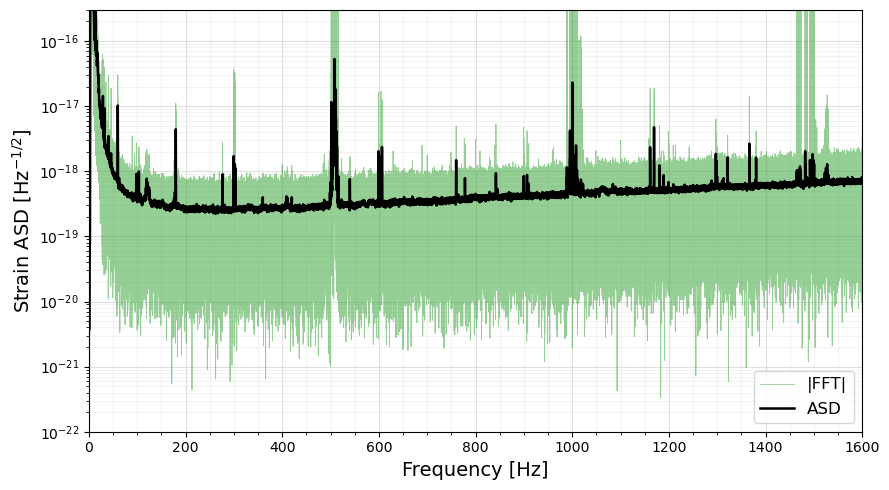

In [22]:
freq_cutoff = 1600

plt.figure(figsize=(9, 5))

plt.semilogy(
    freqs[freqs < freq_cutoff],
    np.abs(sft[freqs < freq_cutoff]),
    color='tab:green', alpha=0.5, lw=0.6,
    label='|FFT|'
)

plt.semilogy(
    freqs_sps[freqs_sps < freq_cutoff],
    sps[freqs_sps < freq_cutoff] / norm_factor,
    color='black', lw=1.8,
    label='ASD'
)

plt.xlim(0, freq_cutoff)
plt.ylim(1e-22, 3e-16)

plt.xlabel('Frequency [Hz]', fontsize=14)
plt.ylabel(r'Strain ASD [$\mathrm{Hz}^{-1/2}$]', fontsize=14)

plt.grid(True, which='major', alpha=0.4)
plt.grid(True, which='minor', alpha=0.15)
plt.minorticks_on()

plt.legend(frameon=True, fontsize=12)
plt.tight_layout()


## Plot the distribution of the ratio of FFT power to the estimate of the PSD

This distribution, in Gaussian noise, should be exponential, with a mean and standard deviation of one.

#### Plot in log-space diagnostic without excluding tail


Distribution in log space for exponential noise

Assume that the normalized Fourier power in a single frequency bin is
distributed as an exponential random variable,
as expected for stationary Gaussian noise:
\begin{equation}
X \sim \mathrm{Exponential}(1),
\end{equation}
with probability density function
\begin{equation}
p_X(x) = e^{-x}, \qquad x \ge 0.
\end{equation}

We define a new variable by taking the base-10 logarithm,
\begin{equation}
Y = \log_{10} X .
\end{equation}

To obtain the probability density function of \(Y\), we use the standard
change-of-variables formula.  
Since the transformation is monotonic, we write
\begin{equation}
X = 10^Y,
\end{equation}
with Jacobian
\begin{equation}
\frac{dX}{dY} = \ln(10)\,10^Y .
\end{equation}

The PDF of \(Y\) is therefore
\begin{equation}
\begin{aligned}
p_Y(y)
&= p_X(10^y)\,\left|\frac{dX}{dY}\right| \\
&= e^{-10^y}\,\ln(10)\,10^y .
\end{aligned}
\end{equation}

Hence,
\begin{equation}
\boxed{
p_Y(y) = \ln(10)\,10^y\,\exp(-10^y)
}
\end{equation}

This expression gives the expected distribution when plotting
$(\log_{10}(|X_k|^2 / S_k))$ for exponentially distributed noise power.
The distribution peaks at $(y = 0)$, corresponding to unit-mean
normalized power, and exhibits a rapidly suppressed high-power tail.


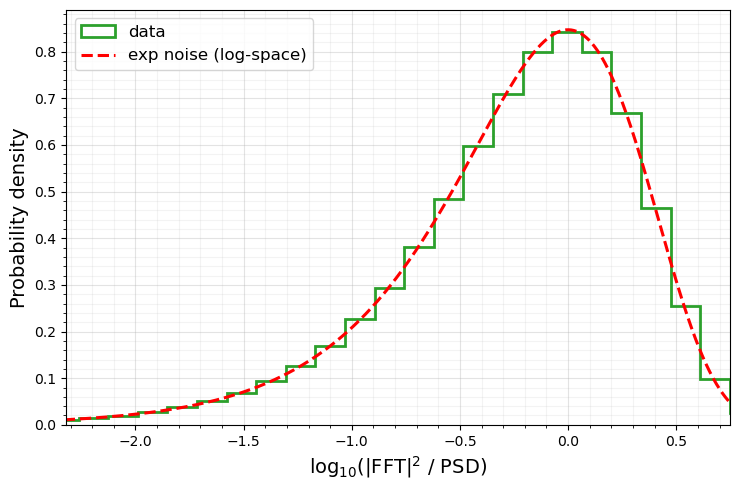

mean:  1516.6268
std:  1329058.5
median:  0.6991402


In [23]:
sps_full = np.repeat(sps, sfdb_head.red) / norm_factor

psd_full = sps_full**2                   # strain^2 / Hz

power_ratio = (np.abs(sft)**2) / psd_full          # should be ~ exponential(1)


mask = np.isfinite(power_ratio) & (power_ratio > 0) & (freqs < freq_cutoff)

y = np.log10(power_ratio[mask])
plt.figure(figsize=(7.5, 5))

# histogram
plt.hist(
    y,
    bins=120,
    density=True,
    histtype='step',
    lw=2.0,
    color='tab:green',
    label='data'
)

# theoretical PDF in log-space
yy = np.linspace(np.percentile(y, 0.1), np.percentile(y, 99.9), 1000)
pdf_y = np.log(10) * (10**yy) * np.exp(-10**yy)

plt.plot(
    yy,
    pdf_y,
    'r--',
    lw=2.2,
    label='exp noise (log-space)'
)

# labels
plt.xlabel(r'$\log_{10}$(|FFT|$^2$ / PSD)', fontsize=14)
plt.ylabel('Probability density', fontsize=14)

plt.grid(True, which='major', alpha=0.35)
plt.grid(True, which='minor', alpha=0.15)
plt.minorticks_on()

# limits (avoid ugly tails) -- note that there is a tail in the data since it is non gaussian noise
plt.xlim(np.percentile(y, 0.5), np.percentile(y, 99.5))
plt.ylim(bottom=0)

# legend
plt.legend(frameon=True, fontsize=12, loc='upper left')

plt.tight_layout()
plt.show()
print("mean: ",np.mean(power_ratio[mask]))
print("std: ",np.std(power_ratio[mask]))
print("median: ",np.median(power_ratio[mask]))


We see that the mean and standard deviation deviate significantly from those expected from the exponential distribution. This is due to non-Gaussian noise lines that are visible in the spectra. Let's try removing the tail of the distribution and see if things improve

#### Plot in linear-space when excluding tail

In the previous figure we examined the distribution of the normalized power
$(|{\rm FFT}|^2 / {\rm PSD}$) in logarithmic space, which emphasizes the bulk of
the distribution and allows a clean comparison with the expected exponential
form.

In the following figure we repeat the comparison **in linear space**, and
**exclude the high-power tail**.  This is done intentionally: real
gravitational-wave data are not perfectly Gaussian, and rare large excursions
can arise from narrow spectral lines, nonstationarity, or transient noise.
While these outliers strongly affect moments such as the mean and variance,
they are part of the true noise distribution and should not be artificially
removed in this diagnostic.

The linear-space histogram therefore provides a complementary view,
illustrating both the agreement with the exponential expectation in the core
of the distribution and the presence of heavy tails associated with
non-Gaussian noise.


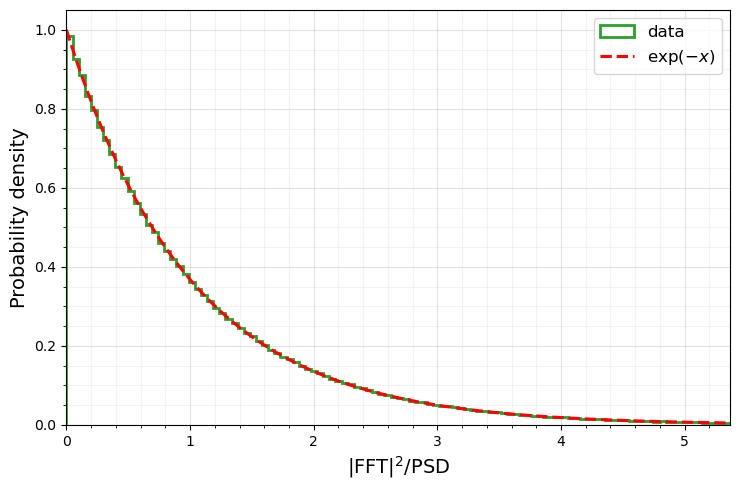

mean: 1.0083704
std: 1.0109369
median: 0.6981304


In [24]:
xv = power_ratio[mask]
xv = xv[xv < np.percentile(xv, 99.9)]

plt.figure(figsize=(7.5, 5))

# Histogram (linear space)
plt.hist(
    xv,
    bins=200,
    density=True,
    histtype='step',
    lw=2.0,
    color='tab:green',
    label='data'
)

# Theoretical exponential PDF (mean=1)
xx = np.linspace(0, np.percentile(xv, 99.9), 2000)  # just for drawing the curve nicely
plt.plot(
    xx,
    np.exp(-xx),
    'r--',
    lw=2.2,
    label=r'$\exp(-x)$'
)

plt.xlabel(r'$|{\rm FFT}|^2 / {\rm PSD}$', fontsize=14)
plt.ylabel('Probability density', fontsize=14)

plt.grid(True, which='major', alpha=0.35)
plt.grid(True, which='minor', alpha=0.15)
plt.minorticks_on()

# No tail clipping of the data, but you *do* want sane axes for visibility:
plt.xlim(0, np.percentile(xv, 99.5))
plt.ylim(bottom=0)

plt.legend(frameon=True, fontsize=12, loc='upper right')

plt.tight_layout()
plt.show()

print("mean:", np.mean(xv))
print("std:", np.std(xv))
print("median:", np.median(xv))
